In [ ]:
import sqlite3 as sql
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt

print('libraries loaded')

libraries loaded


In [3]:
connection = sql.connect("../UAS_Tracker.db")

**Insight 1: Median and IQR by fiscal week**

In [4]:
pd.read_sql_query("SELECT action_date, federal_action_obligation FROM contracts_past_transactions", connection)

,action_date,federal_action_obligation
0,2020-05-21,0.00
1,2020-05-22,90000.00
2,2020-06-30,45000.00
3,2020-09-16,248751.00
4,2020-09-24,0.00
...,...,...
6341,2025-09-04,-62983.76
6342,2025-01-10,0.00
6343,2025-06-11,0.00
6344,2025-03-11,8350.00


In [5]:
df = pd.read_sql_query("SELECT action_date, federal_action_obligation FROM contracts_past_transactions", connection)

In [6]:
df['action_date'] = pd.to_datetime(df['action_date'])

In [7]:
df['fy'] = df['action_date'].dt.year + (df['action_date'].dt.month >= 10).astype(int)


In [ ]:
df['fy_start'] = pd.to_datetime(df['fy'].astype(str) + '-10-01') - pd.DateOffset(years=1)

In [9]:
df['fiscal_week'] = (df['action_date'] - df['fy_start']).dt.days // 7

In [10]:
weekly = df.groupby(['fy', 'fiscal_week'])['federal_action_obligation'].sum().reset_index()

In [11]:
stats = weekly.groupby('fiscal_week')['federal_action_obligation'].agg(
    median='median',
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75),
    n='size'
).reset_index()

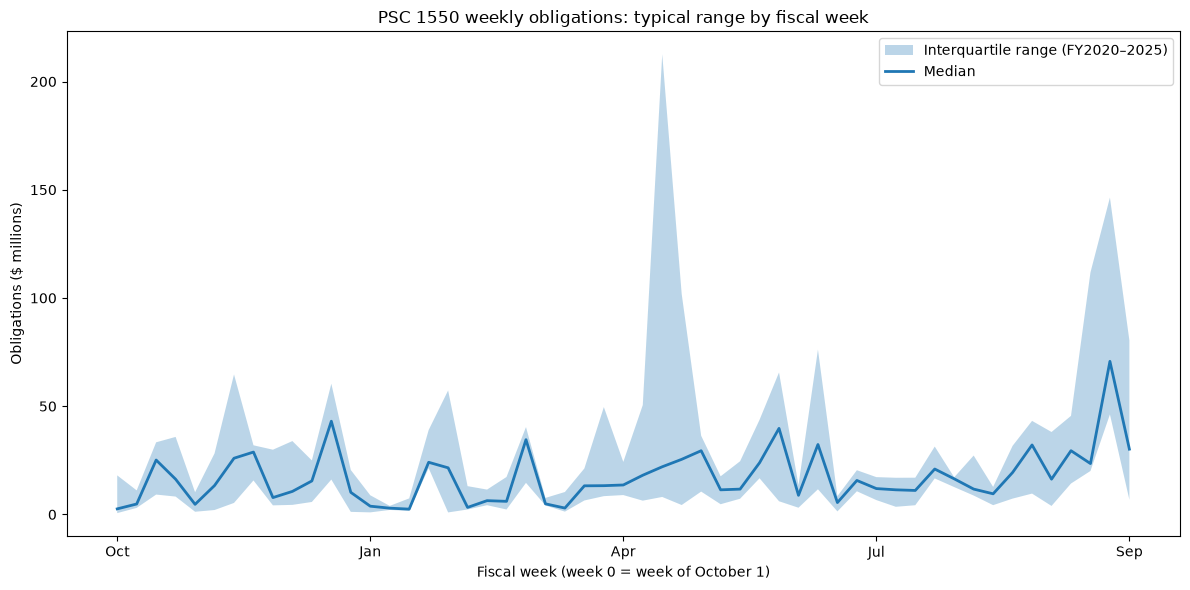

In [12]:
stats['median_m'] = stats['median'] / 1_000_000
stats['q25_m'] = stats['q25'] / 1_000_000
stats['q75_m'] = stats['q75'] / 1_000_000

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(stats['fiscal_week'], stats['q25_m'], stats['q75_m'],
                alpha=0.3, label='Interquartile range (FY2020–2025)')

ax.plot(stats['fiscal_week'], stats['median_m'],
        linewidth=2, label='Median')

ax.set_xlabel('Fiscal week (week 0 = week of October 1)')
ax.set_ylabel('Obligations ($ millions)')
ax.set_title('PSC 1550 weekly obligations: typical range by fiscal week')
ax.set_xticks([0, 13, 26, 39, 52])
ax.set_xticklabels(['Oct', 'Jan', 'Apr', 'Jul', 'Sep'])
ax.legend()

plt.tight_layout()
plt.show()

**Insight 2: Median and IQR by fiscal month**

In [13]:
df['fiscal_month'] = (df['action_date'].dt.month - 10) % 12 + 1

In [14]:
monthly = df.groupby(['fy', 'fiscal_month'])['federal_action_obligation'].sum().reset_index()

In [15]:
stats_m = monthly.groupby('fiscal_month')['federal_action_obligation'].agg(
    median='median',
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75)
).reset_index()

for col in ['median', 'q25', 'q75']:
    stats_m[col] = stats_m[col] / 1_000_000

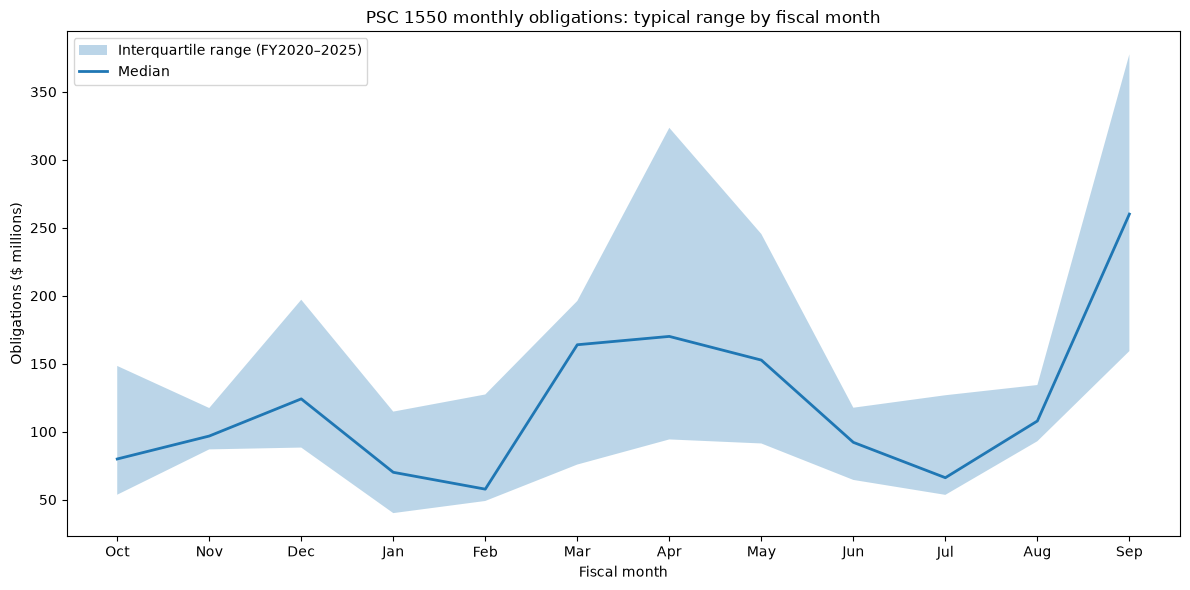

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(stats_m['fiscal_month'], stats_m['q25'], stats_m['q75'],
                alpha=0.3, label='Interquartile range (FY2020–2025)')

ax.plot(stats_m['fiscal_month'], stats_m['median'],
        linewidth=2, label='Median')

ax.set_xlabel('Fiscal month')
ax.set_ylabel('Obligations ($ millions)')
ax.set_title('PSC 1550 monthly obligations: typical range by fiscal month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
ax.legend()

plt.tight_layout()
plt.show()

**Insight 2: Weekly rankings**

In [25]:
df.head

<bound method NDFrame.head of      action_date  federal_action_obligation    fy   fy_start  fiscal_week  \
0     2020-05-21                       0.00  2020 2019-10-01           33   
1     2020-05-22                   90000.00  2020 2019-10-01           33   
2     2020-06-30                   45000.00  2020 2019-10-01           39   
3     2020-09-16                  248751.00  2020 2019-10-01           50   
4     2020-09-24                       0.00  2020 2019-10-01           51   
...          ...                        ...   ...        ...          ...   
6341  2025-09-04                  -62983.76  2025 2024-10-01           48   
6342  2025-01-10                       0.00  2025 2024-10-01           14   
6343  2025-06-11                       0.00  2025 2024-10-01           36   
6344  2025-03-11                    8350.00  2025 2024-10-01           23   
6345  2024-12-05                       0.00  2025 2024-10-01            9   

      fiscal_month  
0                8  
1  

In [ ]:
def weekly_rank(weekly_amount, fiscal_week, weekly_history):
    reference = weekly_history[(weekly_history['fiscal_week'] >= fiscal_week - 2) & (weekly_history['fiscal_week'] <= fiscal_week + 2)]['federal_action_obligation']
    # I'm choosing within the range of 5 weeks because it reflects both seasonality and gives a sample size of 5 similar weeks across 6 years.
    percentile = (reference < weekly_amount).sum() / len(reference) * 100
    rank = (reference >= weekly_amount).sum() + 1
    reference_median = reference.median()
    reference_count = len(reference)
    return percentile, rank, reference_median, reference_count

In [37]:
weekly_rank(weekly_amount=100000000, fiscal_week=40, weekly_history= weekly)

(np.float64(96.66666666666667), np.int64(2), np.float64(16347036.99), 30)

In [39]:
import requests

In [43]:
from datetime import timedelta, date

In [46]:
today_last_week = dt.date.today() - timedelta(days=7)
today_last_week_str = today_last_week.isoformat()
today_str = dt.date.today().isoformat()

In [38]:
cursor = connection.cursor()

In [50]:
insert_string = "INSERT OR REPLACE INTO contracts_weekly_transactions_all (award_id, action_date, date_added, transaction_amount, transaction_description, generated_internal_id, mod, recipient_name, recipient_uei, awarding_agency, award_type, action_type) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)"

In [51]:
transactions = []

page = 1

ifNextPage = True

while ifNextPage:
    response = requests.post(
        url = "https://api.usaspending.gov/api/v2/search/spending_by_transaction/",
        json = {
            "filters": {
                    "award_type_codes": ["A", "B", "C", "D"],
                    "psc_codes": ["1550"],
                "time_period": [{"start_date": today_last_week_str, "end_date": today_str}]
        },
        "fields": [
                "Award ID",
                "Action Date",
                "Transaction Amount",
                "Transaction Description",
                "generated_internal_id",
                "Mod",
                "Recipient Name",
                "Recipient UEI",
                "Awarding Agency",
                "Award Type",
                "Action Type",
        ],
        "page": page,
        "limit": 100,
        "sort": "Action Date"
    }
    )

    ifNextPage = response.json()["page_metadata"]["hasNext"]
    page = page + 1
    transactions.extend(response.json()["results"])

for transaction in transactions:
        cursor.execute (insert_string,(
        transaction["Award ID"],
        transaction["Action Date"],
        today_str,
        float(transaction.get("Transaction Amount") or 0),
        transaction["Transaction Description"],
        transaction["generated_internal_id"],
        transaction["Mod"],
        transaction["Recipient Name"],
        transaction["Recipient UEI"],
        transaction["Awarding Agency"],
        transaction["Award Type"],
        transaction["Action Type"],
    ))
connection.commit()

In [57]:
weekly_amount_query = "SELECT SUM(transaction_amount) AS total FROM contracts_weekly_transactions_all WHERE action_date >= ? AND action_date <= ?"
weekly_amount = pd.read_sql_query(weekly_amount_query, connection, params=(today_last_week_str, today_str)).iloc[0]['total']
print(weekly_amount)

2840576.41


In [54]:
fiscal_year = (today_last_week.year) + (today_last_week.month >= 10)
fiscal_year_start = dt.date(fiscal_year - 1, 10, 1)
fiscal_week = (today_last_week - fiscal_year_start).days // 7

In [58]:
weekly_rank(weekly_amount=weekly_amount, fiscal_week=fiscal_week, weekly_history=weekly)

(np.float64(8.333333333333332),
 np.int64(23),
 np.float64(40088211.760000005),
 24)

**Insight 3: Competition Metrics**

In [62]:
competed_categories = [
    'FULL AND OPEN COMPETITION',
    'COMPETED UNDER SAP',
    'FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES',
]

comp = pd.read_sql_query(
    """SELECT extent_competed, type_of_set_aside,
              action_date_fiscal_year AS fy,
              federal_action_obligation AS amt
       FROM contracts_past_transactions""",
    connection
)

comp = comp[comp['extent_competed'].notna()]
comp['competed'] = comp['extent_competed'].isin(competed_categories)
comp['competed_amt'] = comp['amt'].where(comp['competed'], 0)

trend = comp.groupby('fy').agg(
    n=('competed', 'size'),
    pct_competed=('competed', 'mean'),
    total_amt=('amt', 'sum'),
    competed_amt=('competed_amt', 'sum'),
).reset_index()

trend['pct_competed'] = (trend['pct_competed'] * 100).round(1)
trend['pct_dollars_competed'] = (trend['competed_amt'] / trend['total_amt'] * 100).round(1)

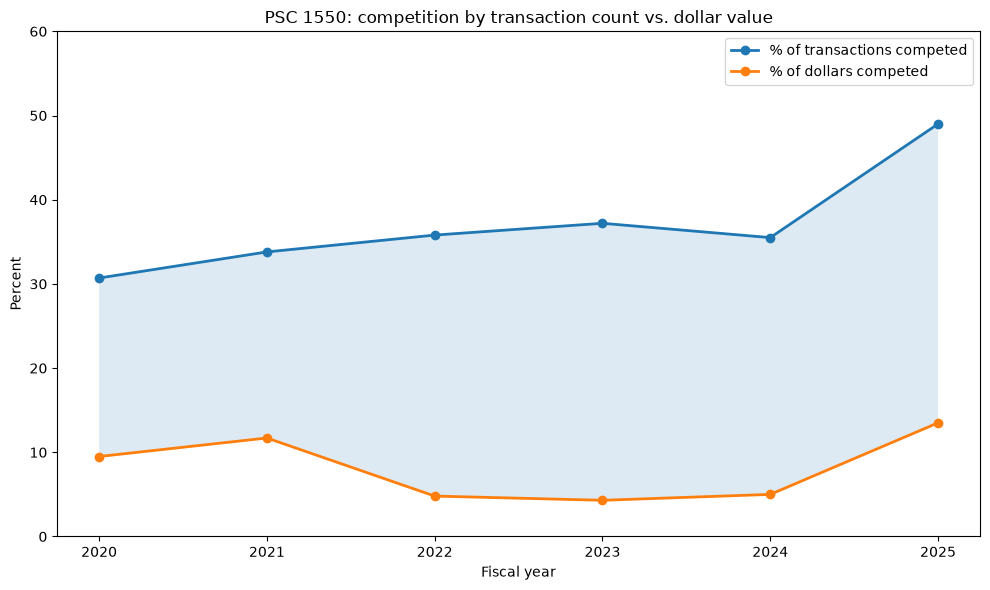

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(trend['fy'], trend['pct_competed'],
        marker='o', linewidth=2, label='% of transactions competed')

ax.plot(trend['fy'], trend['pct_dollars_competed'],
        marker='o', linewidth=2, label='% of dollars competed')

ax.fill_between(trend['fy'], trend['pct_dollars_competed'], trend['pct_competed'],
                alpha=0.15)

ax.set_ylabel('Percent')
ax.set_xlabel('Fiscal year')
ax.set_title('PSC 1550: competition by transaction count vs. dollar value')
ax.set_xticks(trend['fy'])
ax.set_ylim(0, 60)
ax.legend()

plt.tight_layout()
plt.show()